# Anomaly Detection


In [1]:
import matplotlib.pyplot as plt
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import (
    OneHotEncoder,
    StandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.functions import vector_to_array
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, unix_timestamp
from pyspark.sql.types import DoubleType

In [2]:
spark = (
    SparkSession.builder.config("spark.executor.memory", "10g")
    .config("spark.driver.memory", "10g")
    .appName("anomaly_detection")
    .getOrCreate()
)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/22 14:06:22 WARN Utils: Your hostname, legion-5i, resolves to a loopback address: 127.0.1.1; using 192.168.1.12 instead (on interface wlp0s20f3)
25/10/22 14:06:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/22 14:06:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Clustering


In [3]:
df = spark.read.parquet("datasets/yellow_tripdata_2015-01.parquet")
df.show()

+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       1| 2015-01-13 11:46:19|  2015-01-13 12:08:42|              2|          2.6|   -74.00537109375|40.737003326416016|         1|    

In [4]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RateCodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)



In [5]:
def clean_data(data):
    """Clean impossible values based on domain analysis.
    Args:
        data (DataFrame): Input data.
    Returns:
        DataFrame: Data with invalid records removed.
    """

    data = data.na.drop()

    data = data.where(
        data.pickup_longitude.between(-74.15, -73.7004)
        & data.pickup_latitude.between(40.5774, 40.9176)
        & data.dropoff_longitude.between(-74.15, -73.7004)
        & data.dropoff_latitude.between(40.5774, 40.9176)
    )

    data = data.withColumn(
        "trip_duration",
        (
            unix_timestamp("tpep_dropoff_datetime")
            - unix_timestamp("tpep_pickup_datetime")
        )
        / 60,
    )

    data = data.where(data.trip_duration.between(0, 12 * 60))

    data = data.drop("tpep_pickup_datetime", "tpep_dropoff_datetime")

    data = data.where(data.passenger_count.between(0, 6))

    data = data.where(data.extra.between(0, 1.5))

    data = data.where(col("mta_tax") == 0.5)

    data = data.where(
        (col("improvement_surcharge") == 0.3) | (col("improvement_surcharge") == 0.0)
    )

    return data

In [6]:
def clustering_score(input_data, k):
    indexer = StringIndexer(
        inputCols=["store_and_fwd_flag", "RateCodeID"],
        outputCols=["store_and_fwd_flag_indexed", "RateCodeID_indexed"],
    )

    encoder = OneHotEncoder(
        inputCols=[
            "VendorID",
            "RateCodeID_indexed",
            "store_and_fwd_flag_indexed",
            "payment_type",
        ],
        outputCols=[
            "VendorID_vec",
            "RateCodeID_vec",
            "store_and_fwd_flag_vec",
            "payment_type_vec",
        ],
        handleInvalid="keep",
    )

    assembler = VectorAssembler(
        inputCols=[
            "passenger_count",
            "trip_distance",
            "pickup_longitude",
            "pickup_latitude",
            "dropoff_longitude",
            "dropoff_latitude",
            "fare_amount",
            "extra",
            "mta_tax",
            "tip_amount",
            "tolls_amount",
            "improvement_surcharge",
            "total_amount",
        ]
        + [
            "VendorID_vec",
            "RateCodeID_vec",
            "store_and_fwd_flag_vec",
            "payment_type_vec",
        ],
        outputCol="feature_vector",
    )

    scaler = StandardScaler(
        inputCol="feature_vector", outputCol="scaled_feature_vector"
    )

    k_means = KMeans(
        featuresCol="scaled_feature_vector",
        predictionCol="cluster",
        k=k,
        seed=42,
    )

    pipeline = Pipeline(stages=[indexer, encoder, assembler, scaler, k_means])
    model = pipeline.fit(input_data)
    training_cost = model.stages[-1].summary.trainingCost
    return model, training_cost

In [7]:
df = clean_data(df)
df.cache()

DataFrame[VendorID: int, passenger_count: int, trip_distance: double, pickup_longitude: double, pickup_latitude: double, RateCodeID: int, store_and_fwd_flag: string, dropoff_longitude: double, dropoff_latitude: double, payment_type: int, fare_amount: double, extra: double, mta_tax: double, tip_amount: double, tolls_amount: double, improvement_surcharge: double, total_amount: double, trip_duration: double]

In [8]:
x = []
y = []
for k in range(2, 103, 20):
    _, cost = clustering_score(df, k)
    x.append(k)
    y.append(cost)
    print(k, cost)

25/10/22 14:06:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


2 321163481.82816875


22 88051874.43591726


42 55991769.314202674


62 34775846.745480165


82 30299165.640795268


102 25952642.129513822


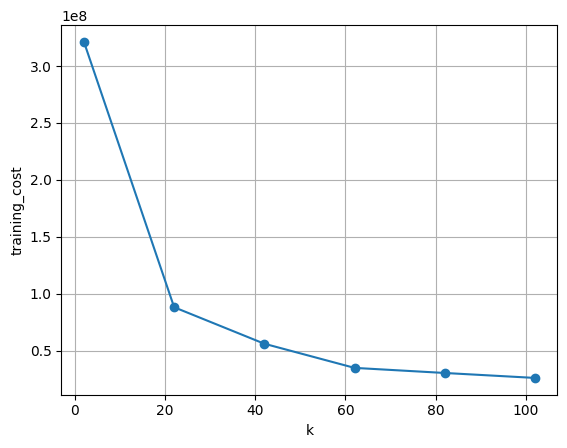

In [9]:
plt.plot(x, y, marker="o")
plt.xlabel("k")
plt.ylabel("training_cost")
plt.grid(True)
plt.show()

In [10]:
pipeline_model, _ = clustering_score(df, 60)
clustered_data = pipeline_model.transform(df)
clustered_data.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+-------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|cluster|
+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+-------------

In [11]:
clustered_data.groupBy("cluster").count().orderBy("cluster").show()

+-------+------+
|cluster| count|
+-------+------+
|      0|696799|
|      1|512258|
|      2|   116|
|      3|  3658|
|      4| 33491|
|      5|    25|
|      6|     1|
|      7|     6|
|      8|301441|
|      9|230748|
|     10|113465|
|     11|    41|
|     12|105146|
|     13|  1790|
|     14|438981|
|     15|442497|
|     16|  9140|
|     17|149441|
|     18| 75559|
|     19|320081|
+-------+------+
only showing top 20 rows


In [12]:
centers = pipeline_model.stages[-1].clusterCenters()
centers

[array([ 9.50687124e-01,  1.76670664e-04, -2.09431874e+03,  1.51298556e+03,
        -2.32874534e+03,  1.33462368e+03,  9.97420478e-01,  3.61033601e-03,
         0.00000000e+00,  1.57984339e-03,  2.77564854e-05,  4.37378276e+00,
         1.05114080e-02,  0.00000000e+00,  0.00000000e+00,  2.00300256e+00,
         7.54255044e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.08323978e+01,
         0.00000000e+00,  0.00000000e+00,  2.05926280e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]),
 array([ 9.69648684e-01,  8.38816957e-04, -2.09496257e+03,  1.51163623e+03,
        -2.32934191e+03,  1.33348716e+03,  9.57491741e-01,  1.38368086e+00,
         0.00000000e+00,  1.68515144e-03,  2.36903736e-05,  4.37378276e+00,
         1.07326601e-02,  0.00000000e+00,  2.00300256e+00,  0.00000000e+00,
         7.54255044e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0

In [13]:
evaluator = ClusteringEvaluator(
    predictionCol="cluster", featuresCol="scaled_feature_vector"
)
silhouette_score = evaluator.evaluate(clustered_data)
silhouette_score

0.3479288984145455

Compute distance to assigned cluster


In [14]:
center_li = [c.tolist() for c in centers]


def distance_to_centroid(vec, cluster):
    center = center_li[cluster]
    return sum((x - y) ** 2 for x, y in zip(vec, center)) ** 0.5


calculate_distance = udf(distance_to_centroid, DoubleType())

In [15]:
clustered_data = clustered_data.withColumn(
    "scaled_feature_array", vector_to_array(col("scaled_feature_vector"))
).withColumn(
    "distance_to_centroid",
    calculate_distance(col("scaled_feature_array"), col("cluster")),
)
clustered_data.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+-------+--------------------+--------------------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|cluster|scaled_feature_array|distance_to_centroid|
+--------+---------------+-------------+----------------

Analyze the distances to find threshold


In [16]:
clustered_data.plot.hist(
    column="distance_to_centroid", title="distance_to_centroid"
).show()
clustered_data.plot.box(column="distance_to_centroid").show()

25/10/22 14:28:03 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.
25/10/22 14:28:03 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.
25/10/22 14:28:03 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.
25/10/22 14:28:56 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.


## Detect Anomalies


In [17]:
new_data = spark.read.parquet("datasets/yellow_tripdata_2016-01.parquet")
new_data.show()

+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RatecodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       2| 2016-01-03 17:09:11|  2016-01-03 17:21:18|              6|         2.13|-73.98211669921875| 40.73194885253906|         1|    

In [18]:
new_data.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)



In [19]:
new_data = clean_data(new_data)
new_data.cache()

DataFrame[VendorID: int, passenger_count: int, trip_distance: double, pickup_longitude: double, pickup_latitude: double, RatecodeID: int, store_and_fwd_flag: string, dropoff_longitude: double, dropoff_latitude: double, payment_type: int, fare_amount: double, extra: double, mta_tax: double, tip_amount: double, tolls_amount: double, improvement_surcharge: double, total_amount: double, trip_duration: double]

In [20]:
new_clustered_data = pipeline_model.transform(new_data)
new_clustered_data.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+-------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RatecodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|cluster|
+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+-------------

In [21]:
new_clustered_data = new_clustered_data.withColumn(
    "scaled_feature_array", vector_to_array(col("scaled_feature_vector"))
).withColumn(
    "distance_to_centroid",
    calculate_distance(col("scaled_feature_array"), col("cluster")),
)
new_clustered_data.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+-------+--------------------+--------------------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RatecodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|     trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|cluster|scaled_feature_array|distance_to_centroid|
+--------+---------------+-------------+----------------

In [22]:
anomalies = new_clustered_data.where(~(col("distance_to_centroid").between(0, 42.8)))
anomalies.show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+-------+--------------------+--------------------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RatecodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|      trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|cluster|scaled_feature_array|distance_to_centroid|
+--------+---------------+-------------+--------------

In [23]:
anomalies.orderBy("distance_to_centroid", ascending=False).show()

+--------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------------+------------------+-------------+--------------+----------------------+----------------+--------------------+---------------------+-------+--------------------+--------------------+
|VendorID|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RatecodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|      trip_duration|store_and_fwd_flag_indexed|RateCodeID_indexed| VendorID_vec|RateCodeID_vec|store_and_fwd_flag_vec|payment_type_vec|      feature_vector|scaled_feature_vector|cluster|scaled_feature_array|distance_to_centroid|
+--------+---------------+-------------+--------------

In [24]:
anomalies.count()

54